# Predictive Analytics: Neural Network – Advanced v8

Controlled ablation based on the best final v7 model. V8 keeps the winning loss, sample weights, hidden layers and learning rate and adds only an `hour_of_week` embedding.

In [1]:
from pathlib import Path
import random
import numpy as np
import polars as pl
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from helper_functions import get_torch_device, load_model_from_checkpoint, plot_regression_diagnostics, plot_learning_curves
from matplotlib import pyplot as plt

from run_config import MODELS_DIR, PATHS

SPATIAL_UNIT = 'community_areas'
TIME_UNIT = '4h'
DATASET_STEM = f'GOLD_{TIME_UNIT.upper()}_DEMAND_{SPATIAL_UNIT.upper()}'
MODEL_TAG = f'{SPATIAL_UNIT}_{TIME_UNIT}'
TRAINING_DATA_PATH = PATHS.train_test_dir / f'{DATASET_STEM}_TRAIN.parquet'
VAL_DATA_PATH = PATHS.train_test_dir / f'{DATASET_STEM}_VAL.parquet'
MODEL_PATH = MODELS_DIR
MODEL_PATH.mkdir(parents=True, exist_ok=True)
V8_CHECKPOINT_PATH = MODEL_PATH / f'advanced_v8_{MODEL_TAG}_hour_of_week_embedding.pt'
TARGET_COL, COMMUNITY_COL = 'trip_count', 'community_area'
HIGH_DEMAND_THRESHOLD = 20
GLOBAL_MAE_WEIGHT, HIGH_DEMAND_MAE_WEIGHT = 0.4, 0.6
HOUR_OF_WEEK_EMBEDDING_DIM = 8
BATCH_SIZE, SEED = 1024, 42
MAX_EPOCHS, PATIENCE = 100, 15

EXCLUDE_COLS = {
    TARGET_COL, 'datetime_hour', 'date', '_split_bucket', 'month', 'weekday', 'hour',
    'most_common_payment_type', 'trip_seconds_sum', 'trip_seconds_mean', 'trip_seconds_min',
    'trip_seconds_max', 'trip_miles_sum', 'trip_miles_mean', 'trip_miles_min',
    'trip_miles_max', 'fare_sum', 'fare_mean', 'fare_min', 'fare_max', 'tips_sum',
    'tips_mean', 'tips_min', 'tips_max', 'tolls_sum', 'tolls_mean', 'tolls_min',
    'tolls_max', 'extras_sum', 'extras_mean', 'extras_min', 'extras_max',
    'trip_total_sum', 'trip_total_mean', 'trip_total_min', 'trip_total_max',
}

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

device = get_torch_device()
print('Using device:', device)

Using device: mps


## Find the winning v7 configuration

In [2]:
v7_paths = sorted(MODEL_PATH.glob(f'advanced_v7_{MODEL_TAG}_final_*.pt'))
if not v7_paths:
    raise FileNotFoundError('No final v7 checkpoint found. Run v7 first.')
v7_summaries = [(path, torch.load(path, map_location='cpu', weights_only=False)) for path in v7_paths]
V7_CHECKPOINT_PATH, v7_checkpoint = min(v7_summaries, key=lambda item: item[1]['selection_score'])
V7_CONFIG = v7_checkpoint['config_values']
print('v7 winner:', V7_CHECKPOINT_PATH.name)
print('configuration:', V7_CONFIG)
print('saved selection score:', v7_checkpoint['selection_score'])

FileNotFoundError: No final v7 checkpoint found. Run v7 first.

## Data preparation and hour-of-week IDs

In [ ]:
train_df = pl.read_parquet(TRAINING_DATA_PATH)
val_df = pl.read_parquet(VAL_DATA_PATH)
numeric_feature_cols = [c for c in train_df.columns if c not in EXCLUDE_COLS and c != COMMUNITY_COL]

weekday_min, weekday_max = train_df['weekday'].min(), train_df['weekday'].max()
hour_min, hour_max = train_df['hour'].min(), train_df['hour'].max()
if (weekday_min, weekday_max) == (1, 7):
    weekday_offset = 1
elif (weekday_min, weekday_max) == (0, 6):
    weekday_offset = 0
else:
    raise ValueError(f'Unexpected weekday range: {weekday_min}..{weekday_max}')
if (hour_min, hour_max) != (0, 23):
    raise ValueError(f'Unexpected hour range: {hour_min}..{hour_max}')

def hour_of_week(frame):
    weekday = frame['weekday'].cast(pl.Int64)
    hour = frame['hour'].cast(pl.Int64)
    values = ((weekday - weekday_offset) * 24 + hour).to_numpy()
    assert values.min() >= 0 and values.max() < 168
    return values

community_values = sorted(train_df[COMMUNITY_COL].unique().to_list())
community_to_idx = {value: idx + 1 for idx, value in enumerate(community_values)}
community_train = np.array([community_to_idx.get(v, 0) for v in train_df[COMMUNITY_COL]], dtype=np.int64)
community_val = np.array([community_to_idx.get(v, 0) for v in val_df[COMMUNITY_COL]], dtype=np.int64)

scaler = StandardScaler()
x_train = scaler.fit_transform(train_df.select(numeric_feature_cols).to_numpy()).astype('float32')
x_val = scaler.transform(val_df.select(numeric_feature_cols).to_numpy()).astype('float32')
y_train_original = train_df[TARGET_COL].to_numpy().astype('float32')
y_val_original = val_df[TARGET_COL].to_numpy().astype('float32')
y_train = np.log1p(y_train_original).reshape(-1, 1).astype('float32')
y_val = np.log1p(y_val_original).reshape(-1, 1).astype('float32')

x_train_t, x_val_t = torch.tensor(x_train), torch.tensor(x_val)
community_train_t = torch.tensor(community_train, dtype=torch.long)
community_val_t = torch.tensor(community_val, dtype=torch.long)
hour_week_train_t = torch.tensor(hour_of_week(train_df), dtype=torch.long)
hour_week_val_t = torch.tensor(hour_of_week(val_df), dtype=torch.long)
y_train_t, y_val_t = torch.tensor(y_train), torch.tensor(y_val)
val_dataset_v7 = TensorDataset(x_val_t, community_val_t, y_val_t)
val_dataset_v8 = TensorDataset(x_val_t, community_val_t, hour_week_val_t, y_val_t)
val_loader_v7 = DataLoader(val_dataset_v7, batch_size=BATCH_SIZE, shuffle=False)
val_loader_v8 = DataLoader(val_dataset_v8, batch_size=BATCH_SIZE, shuffle=False)
print(f'weekday={weekday_min}..{weekday_max}, hour={hour_min}..{hour_max}, numeric features={x_train.shape[1]}')

weekday=1..7, hour=0..23, numeric features=22


## V7 and V8 architectures

In [ ]:
def dense_network(input_dim, hidden_dims, dropout):
    layers, current = [], input_dim
    for hidden in hidden_dims:
        layers.extend([nn.Linear(current, hidden), nn.ReLU()])
        if dropout > 0: layers.append(nn.Dropout(dropout))
        current = hidden
    layers.append(nn.Linear(current, 1))
    return nn.Sequential(*layers)

class TaxiDemandAdvancedNNV7(nn.Module):
    def __init__(self, numeric_input_dim, num_communities, embedding_dim=8, hidden_dims=(64, 32), dropout=0.0):
        super().__init__()
        self.community_embedding = nn.Embedding(num_communities, embedding_dim, padding_idx=0)
        self.network = dense_network(numeric_input_dim + embedding_dim, hidden_dims, dropout)
    def forward(self, x, community):
        return self.network(torch.cat([x, self.community_embedding(community)], dim=1))

class TaxiDemandAdvancedNNV8(nn.Module):
    def __init__(self, numeric_input_dim, num_communities, embedding_dim=8, hour_of_week_embedding_dim=8, hidden_dims=(64, 32), dropout=0.0):
        super().__init__()
        self.community_embedding = nn.Embedding(num_communities, embedding_dim, padding_idx=0)
        self.hour_of_week_embedding = nn.Embedding(168, hour_of_week_embedding_dim)
        self.network = dense_network(numeric_input_dim + embedding_dim + hour_of_week_embedding_dim, hidden_dims, dropout)
    def forward(self, x, community, hour_week):
        return self.network(torch.cat([x, self.community_embedding(community), self.hour_of_week_embedding(hour_week)], dim=1))

In [ ]:
def make_criterion(config):
    if config['loss'] == 'l1': return nn.L1Loss(reduction='none')
    if config['loss'] == 'smooth_l1': return nn.SmoothL1Loss(beta=config.get('beta', 0.5), reduction='none')
    raise ValueError(config['loss'])

def sample_weights(y, peak_weight):
    w = np.ones_like(y, dtype=np.float32)
    w[(y > 0) & (y <= 2)] = 1.2; w[(y > 2) & (y <= 10)] = 1.5
    w[(y > 10) & (y <= 20)] = 3.0; w[y > 20] = peak_weight
    return w

def evaluate(model, loader, criterion, with_time):
    model.eval(); log_sum = 0.0; count = 0; true_parts, pred_parts = [], []
    with torch.inference_mode():
        for batch in loader:
            if with_time:
                x, community, hour_week, y = batch
                pred = model(x.to(device), community.to(device), hour_week.to(device))
            else:
                x, community, y = batch
                pred = model(x.to(device), community.to(device))
            y = y.to(device); log_sum += criterion(pred, y).mean().item() * len(y); count += len(y)
            true_parts.append(torch.expm1(y).cpu().numpy().reshape(-1))
            pred_parts.append(torch.clamp(torch.expm1(pred), min=0).cpu().numpy().reshape(-1))
    true = np.rint(np.concatenate(true_parts)).astype(np.int64); pred = np.concatenate(pred_parts)
    error = np.abs(true - pred); high = true > HIGH_DEMAND_THRESHOLD
    metrics = {'val_log_loss': log_sum/count, 'val_mae': float(error.mean()),
               'val_rmse': float(np.sqrt(np.mean((true-pred)**2))),
               'high_demand_mae': float(error[high].mean()),
               'high_demand_median_ae': float(np.median(error[high])),
               'high_demand_rmse': float(np.sqrt(np.mean((true[high]-pred[high])**2)))}
    return metrics, true, pred

## Recalculate the v7 baseline and train v8

In [ ]:
v7_model, _ = load_model_from_checkpoint(TaxiDemandAdvancedNNV7, V7_CHECKPOINT_PATH, device=device)
criterion = make_criterion(V7_CONFIG)
v7_metrics, _, _ = evaluate(v7_model, val_loader_v7, criterion, with_time=False)
BASELINE_VAL_MAE = v7_metrics['val_mae']
BASELINE_HIGH_DEMAND_MAE = v7_metrics['high_demand_mae']
print('recalculated v7 baseline:', v7_metrics)

recalculated v7 baseline: {'val_log_loss': 0.2901776690233695, 'val_mae': 2.172854965067689, 'val_rmse': 8.300638520492921, 'high_demand_mae': 19.764634650826714, 'high_demand_median_ae': 11.258464813232422, 'high_demand_rmse': 31.36333110469012}


In [ ]:
weights_t = torch.tensor(sample_weights(y_train_original, V7_CONFIG['peak_weight']))
train_dataset = TensorDataset(x_train_t, community_train_t, hour_week_train_t, y_train_t, weights_t)
generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=generator)

set_seed()
model_kwargs = {
    'numeric_input_dim': x_train_t.shape[1], 'num_communities': len(community_to_idx)+1,
    'embedding_dim': v7_checkpoint['model_kwargs'].get('embedding_dim', 8),
    'hour_of_week_embedding_dim': HOUR_OF_WEEK_EMBEDDING_DIM,
    'hidden_dims': tuple(V7_CONFIG['hidden_dims']), 'dropout': v7_checkpoint['model_kwargs'].get('dropout', 0.0),
}
model = TaxiDemandAdvancedNNV8(**model_kwargs).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=V7_CONFIG['lr'], weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
best_score, stale = float('inf'), 0
history = []

for epoch in range(1, MAX_EPOCHS + 1):
    model.train(); loss_sum = 0.0; count = 0
    for x, community, hour_week, y, weights in train_loader:
        x, community, hour_week, y, weights = x.to(device), community.to(device), hour_week.to(device), y.to(device), weights.to(device)
        optimizer.zero_grad(); pred = model(x, community, hour_week)
        loss = (criterion(pred, y).reshape(-1) * weights.reshape(-1)).mean()
        loss.backward(); optimizer.step(); loss_sum += loss.item()*len(y); count += len(y)
    metrics, _, _ = evaluate(model, val_loader_v8, criterion, with_time=True)
    score = GLOBAL_MAE_WEIGHT*metrics['val_mae']/BASELINE_VAL_MAE + HIGH_DEMAND_MAE_WEIGHT*metrics['high_demand_mae']/BASELINE_HIGH_DEMAND_MAE
    scheduler.step(metrics['val_mae']); row = {'epoch': epoch, 'train_loss': loss_sum/count, 'selection_score': score, **metrics}; history.append(row)
    if score < best_score:
        best_score, stale = score, 0
        torch.save({**row, 'model_name': f'advanced_v8_{MODEL_TAG}_hour_of_week_embedding', 'model_kwargs': model_kwargs,
                    'model_state_dict': model.state_dict(), 'optimizer_state_dict': optimizer.state_dict(),
                    'scheduler_state_dict': scheduler.state_dict(), 'v7_source_checkpoint': str(V7_CHECKPOINT_PATH),
                    'v7_config': V7_CONFIG, 'numeric_feature_cols': numeric_feature_cols,
                    'community_to_idx': community_to_idx, 'weekday_offset': weekday_offset,
                    'hour_of_week_definition': '(weekday - weekday_offset) * 24 + hour',
                    'target_transform': 'log1p', 'high_demand_threshold': HIGH_DEMAND_THRESHOLD,
                    'baseline_val_mae': BASELINE_VAL_MAE, 'baseline_high_demand_mae': BASELINE_HIGH_DEMAND_MAE}, V8_CHECKPOINT_PATH)
    else: stale += 1
    print(f"{epoch:03d} | score={score:.4f} | MAE={metrics['val_mae']:.4f} | high={metrics['high_demand_mae']:.4f} | stale={stale}/{PATIENCE}")
    if stale >= PATIENCE: break
history_df = pl.DataFrame(history)
history_df.tail()

HISTORY_PATH = (
    Path(MODEL_PATH)
    / f"advanced_v8_{MODEL_TAG}_training_history.parquet"
)

history_df.write_parquet(HISTORY_PATH)

recalculated v7 baseline: {'val_log_loss': 0.2901776690233695, 'val_mae': 2.172854965067689, 'val_rmse': 8.300638520492921, 'high_demand_mae': 19.764634650826714, 'high_demand_median_ae': 11.258464813232422, 'high_demand_rmse': 31.36333110469012}
001 | score=1.4395 | MAE=2.8793 | high=29.9569 | stale=0/15
002 | score=1.2711 | MAE=2.6783 | high=25.6298 | stale=0/15
003 | score=1.1670 | MAE=2.4786 | high=23.4124 | stale=0/15
004 | score=1.1544 | MAE=2.4082 | high=23.4231 | stale=0/15
005 | score=1.1268 | MAE=2.3907 | high=22.6212 | stale=0/15
006 | score=1.1067 | MAE=2.3563 | high=22.1663 | stale=0/15
007 | score=1.2245 | MAE=2.5141 | high=25.0904 | stale=1/15
008 | score=1.1067 | MAE=2.3558 | high=22.1715 | stale=2/15
009 | score=1.1457 | MAE=2.4250 | high=23.0352 | stale=3/15
010 | score=1.0910 | MAE=2.3177 | high=21.8842 | stale=0/15
011 | score=1.1091 | MAE=2.3461 | high=22.3065 | stale=1/15
012 | score=1.0892 | MAE=2.3310 | high=21.7451 | stale=0/15
013 | score=1.0722 | MAE=2.2993 |

epoch,train_loss,selection_score,val_log_loss,val_mae,val_rmse,high_demand_mae,high_demand_median_ae,high_demand_rmse
i64,f64,f64,f64,f64,f64,f64,f64,f64
85,0.410148,1.018914,0.290875,2.20514,8.52747,20.191884,11.528198,32.218477
86,0.410135,1.01868,0.290805,2.205097,8.528475,20.184451,11.510496,32.218721
87,0.410122,1.019505,0.291193,2.210149,8.541403,20.180984,11.499912,32.245793
88,0.410107,1.019029,0.290824,2.205162,8.53301,20.19555,11.541222,32.240301
89,0.410094,1.019813,0.29063,2.204156,8.53712,20.227488,11.561523,32.279328


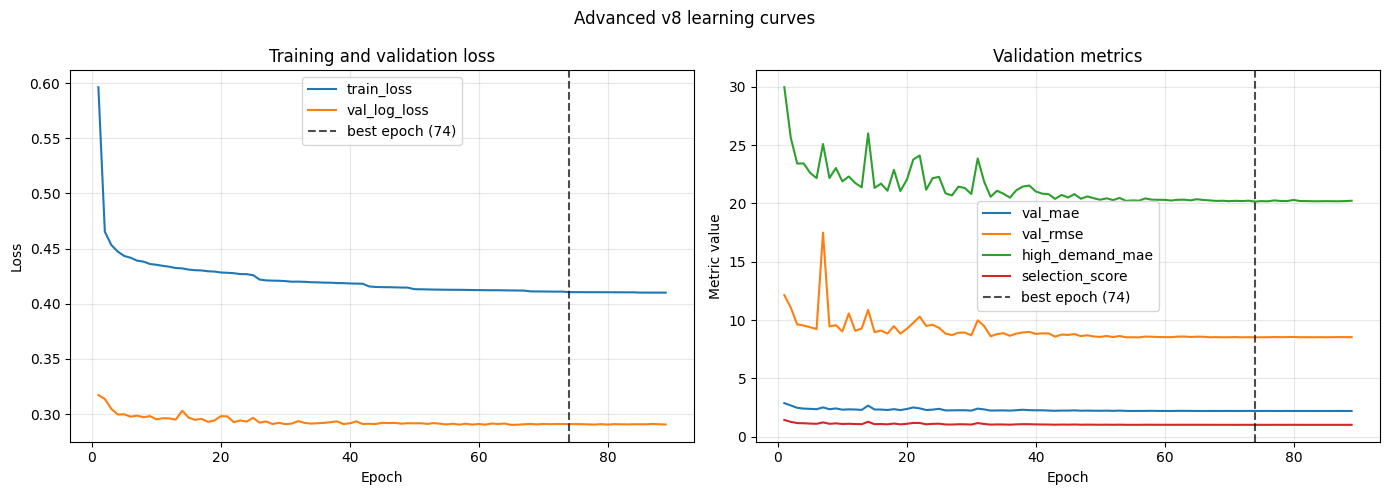

In [ ]:
HISTORY_PATH = (
    Path(MODEL_PATH)
    / f"advanced_v8_{MODEL_TAG}_training_history.parquet"
)

history_df = pl.read_parquet(HISTORY_PATH)
figure = plot_learning_curves(
    history_df,
    title="Advanced v8 learning curves",
)

plt.show()

## Compare v7 and v8 and inspect demand buckets

shape: (2, 10)
┌───────┬────────────┬────────────┬──────────┬───┬────────────┬────────────┬───────────┬───────────┐
│ model ┆ selection_ ┆ val_log_lo ┆ val_mae  ┆ … ┆ high_deman ┆ high_deman ┆ relative_ ┆ relative_ │
│ ---   ┆ score_vs_v ┆ ss         ┆ ---      ┆   ┆ d_median_a ┆ d_rmse     ┆ val_mae   ┆ high_dema │
│ str   ┆ 7          ┆ ---        ┆ f64      ┆   ┆ e          ┆ ---        ┆ ---       ┆ nd_mae    │
│       ┆ ---        ┆ f64        ┆          ┆   ┆ ---        ┆ f64        ┆ f64       ┆ ---       │
│       ┆ f64        ┆            ┆          ┆   ┆ f64        ┆            ┆           ┆ f64       │
╞═══════╪════════════╪════════════╪══════════╪═══╪════════════╪════════════╪═══════════╪═══════════╡
│ v7    ┆ 1.0        ┆ 0.290178   ┆ 2.172855 ┆ … ┆ 11.258465  ┆ 31.363331  ┆ 1.0       ┆ 1.0       │
│ v8    ┆ 1.01795    ┆ 0.291013   ┆ 2.206118 ┆ … ┆ 11.500351  ┆ 32.158745  ┆ 1.015308  ┆ 1.01971   │
└───────┴────────────┴────────────┴──────────┴───┴────────────┴────────────┴

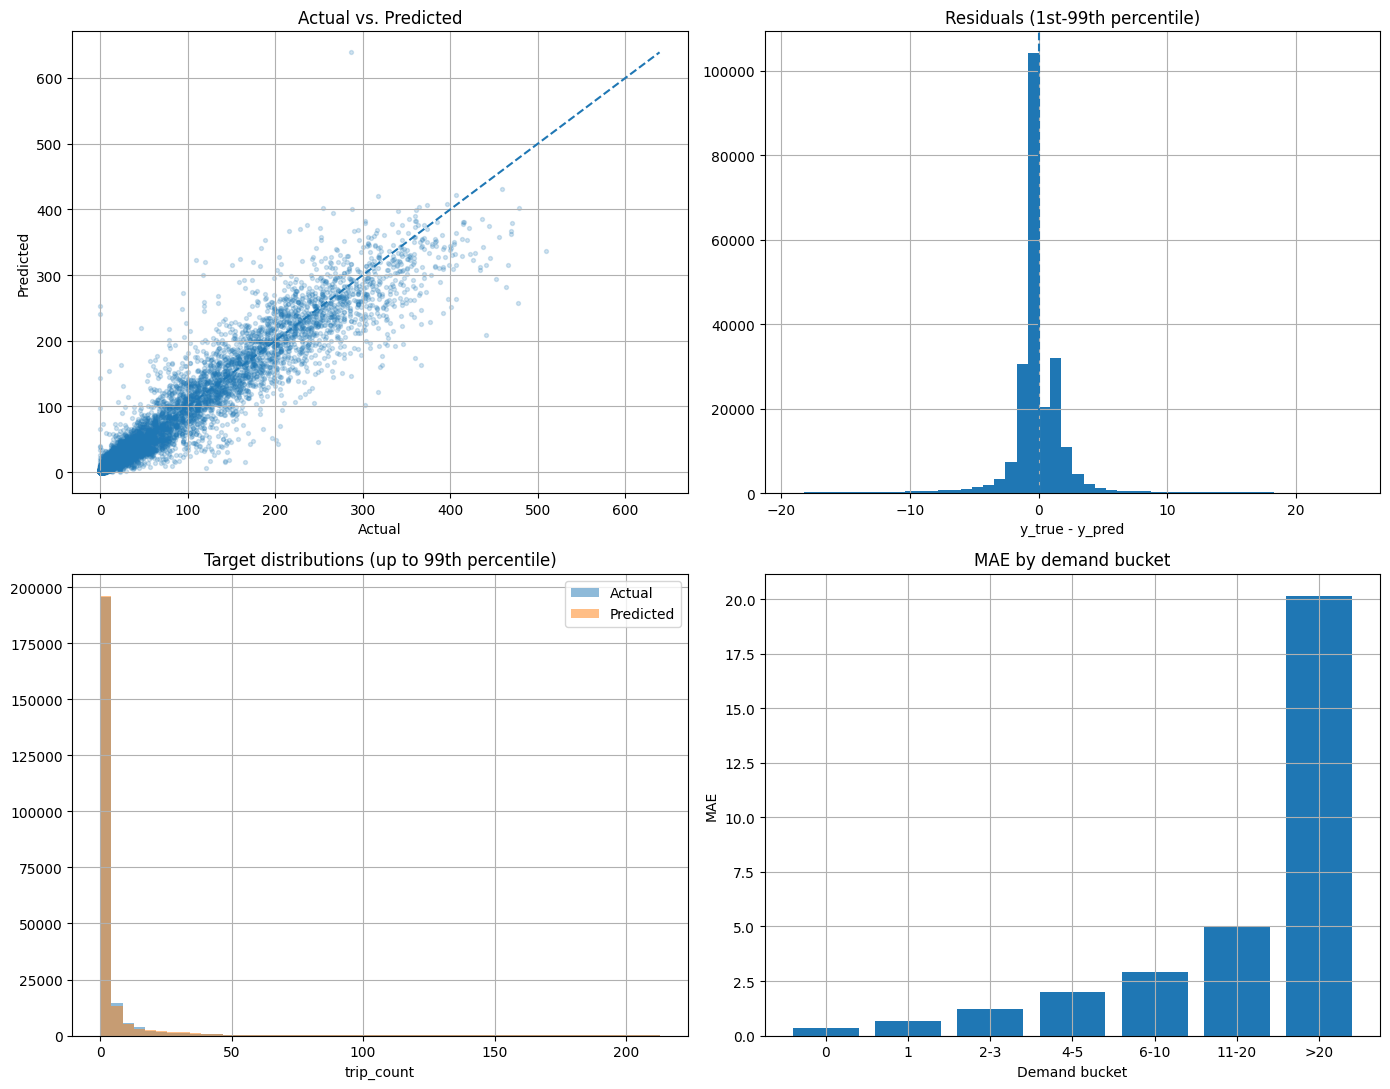

demand_bucket,n_rows,mae,avg_y_true,bucket_order
str,u32,f64,f64,i64
"""0""",103526,0.340491,0.0,0
"""1""",46118,0.679796,1.0,1
"""2-3""",37565,1.199728,2.360495,2
"""4-5""",13616,1.998445,4.397106,3
"""6-10""",12486,2.899444,7.517059,4
"""11-20""",7379,4.987657,14.667028,5
""">20""",15321,20.154203,105.477776,6


In [ ]:
v8_model, v8_checkpoint = load_model_from_checkpoint(TaxiDemandAdvancedNNV8, V8_CHECKPOINT_PATH, device=device)
v8_metrics, y_true, y_pred = evaluate(v8_model, val_loader_v8, criterion, with_time=True)
comparison_df = pl.DataFrame([
    {'model': 'v7', 'selection_score_vs_v7': 1.0, **v7_metrics},
    {'model': 'v8', 'selection_score_vs_v7': v8_checkpoint['selection_score'], **v8_metrics},
]).with_columns(
    (pl.col('val_mae')/BASELINE_VAL_MAE).alias('relative_val_mae'),
    (pl.col('high_demand_mae')/BASELINE_HIGH_DEMAND_MAE).alias('relative_high_demand_mae'),
)
print(comparison_df)

eval_df = pl.DataFrame({'y_true': y_true, 'y_pred': y_pred}).with_columns(
    (pl.col('y_true')-pl.col('y_pred')).alias('residual'),
    (pl.col('y_true')-pl.col('y_pred')).abs().alias('abs_error'),
    ((pl.col('y_true')-pl.col('y_pred'))**2).alias('squared_error'),
)
figure, bucket_df = plot_regression_diagnostics(eval_df)
plt.show()
bucket_df